In [42]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.0 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 20.7 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ----- ---------------------------------- 5.0/36.5 MB 25.1 MB/s eta 0:00:02
   ---------- ----------------------------- 9.7/36.5 MB 24.1 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/36.5 MB 22.5 MB/s eta 0:00:02
   ------------------- -------------------- 17.8/36.5 MB 21.6 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/36.5 MB 21.6 MB/s eta 0:00:01
   ----------------------------- ---------- 26.7/36.5 MB

In [17]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [36]:
merge_cols = [col for col in data_mat.columns if col not in ["G1", "G2", "G3", "absences"]]

data=pd.merge(data_mat, data_por, on=merge_cols, how="outer", suffixes=("_mat", "_por"))
 # 382 students
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,Walc,health,absences_mat,G1_mat,G2_mat,G3_mat,absences_por,G1_por,G2_por,G3_por
0,F,15,R,GT3,T,1,1,at_home,at_home,course,...,2,2,NaN,NaN,NaN,NaN,0.0,13.0,14.0,14.0
1,F,15,R,GT3,T,1,1,at_home,other,home,...,1,2,NaN,NaN,NaN,NaN,1.0,11.0,10.0,11.0
2,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,NaN,NaN,NaN,NaN,4.0,13.0,13.0,13.0
3,F,15,R,GT3,T,1,1,at_home,other,home,...,1,1,2.0,7.0,10.0,10.0,NaN,NaN,NaN,NaN
4,F,15,R,GT3,T,1,1,at_home,services,other,...,1,2,NaN,NaN,NaN,NaN,6.0,10.0,10.0,10.0


In [59]:
print(data.columns)


Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
       'health', 'absences_mat', 'G1_mat', 'G2_mat', 'G3_mat', 'absences_por',
       'G1_por', 'G2_por', 'G3_por'],
      dtype='str')


In [80]:
label = ['course', 'other', 'home', 'reputation']
prop=[data_mat[(data_mat["reason"] == name)]["studytime"].count()/len(data_mat) for name in label]

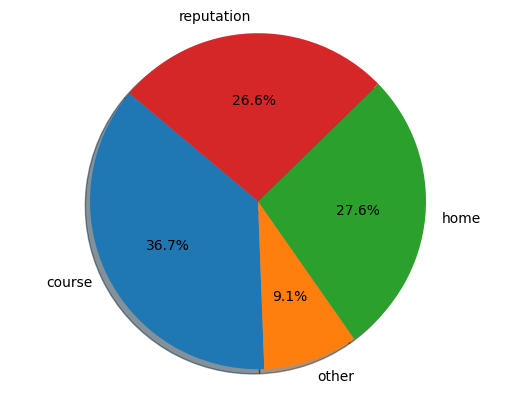

In [82]:
plt.pie(prop, labels=label,autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')
plt.show()

<Axes: xlabel='Dalc', ylabel='G3'>

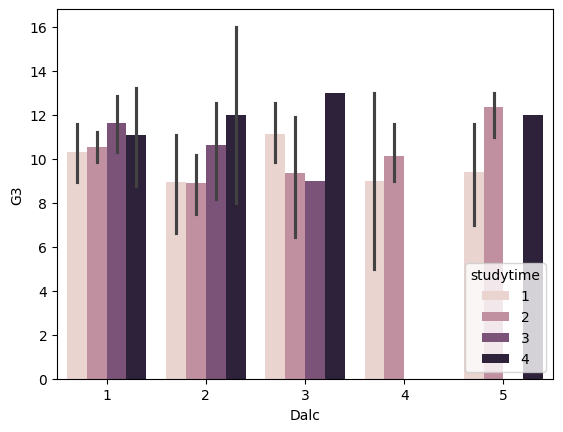

In [85]:
sns.barplot(data_mat, x="Dalc", y="G3", estimator=np.mean, hue = "studytime")